# Pipeline LightGBM — Inhibidores Moleculares

Dataset: 8 proteínas kinasas | Splits **oficiales** train/test del dataset Kaggle

Enfoque bioquímico: proteínas separadas por **localización celular**
- 🔴 **Membrana** (RTK + SFK): `egfr_erbB1`, `hgfr`, `vegfr2`, `tpk_lck`, `tpk_src`
- 🔵 **Citoplasmáticas**: `cdk2`, `gsk3b`, `map_k_p38a`


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

from src.config import DATA_DIR, OUTPUT_DIR, LOCATION_COLORS, LOCATION_LABELS
from src import data_loading, feature_engineering, lgbm_model, interpretation

# Anclar OUTPUT_DIR al root del proyecto (no al CWD de notebooks/)
import src.config as _cfg
_cfg.OUTPUT_DIR = (PROJECT_ROOT / OUTPUT_DIR).resolve()
OUTPUT_DIR = _cfg.OUTPUT_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'plots').mkdir(exist_ok=True)
(OUTPUT_DIR / 'models').mkdir(exist_ok=True)

print(f'Modulos cargados')
print(f'  DATA_DIR   = {DATA_DIR}')
print(f'  OUTPUT_DIR = {OUTPUT_DIR}')
print(f'  plots_dir  = {interpretation.plots_dir()}')


Modulos cargados
  DATA_DIR   = /Users/fabian/Downloads/CANCERDATASET
  OUTPUT_DIR = /Users/fabian/Downloads/CanInh-Model/results
  plots_dir  = /Users/fabian/Downloads/CanInh-Model/results/plots


In [2]:
import run_pipeline
import importlib

importlib.reload(run_pipeline)

print("Iniciando el orquestador principal...")
run_pipeline.run(membrane_only=True)

17:29:47 | INFO | Proteínas detectadas: ['cdk2', 'egfr_erbB1', 'gsk3b', 'hgfr', 'map_k_p38a', 'tpk_lck', 'tpk_src', 'vegfr2']


Iniciando el orquestador principal...


17:29:49 | INFO |   cdk2            | official | train=1558 (1035+ / 523-) | test=332 | cytoplasmic
17:29:53 | INFO |   egfr_erbB1      | official | train=6055 (4372+ / 1683-) | test=882 | membrane
17:29:55 | INFO |   gsk3b           | official | train=1875 (1419+ / 456-) | test=333 | cytoplasmic
17:29:56 | INFO |   hgfr            | official | train=2321 (2045+ / 276-) | test=558 | membrane
17:29:59 | INFO |   map_k_p38a      | official | train=4019 (3549+ / 470-) | test=651 | cytoplasmic
17:30:01 | INFO |   tpk_lck         | official | train=1850 (1384+ / 466-) | test=319 | membrane
17:30:03 | INFO |   tpk_src         | official | train=2954 (1978+ / 976-) | test=633 | membrane
17:30:07 | INFO |   vegfr2          | official | train=6128 (5035+ / 1093-) | test=732 | membrane
17:30:07 | INFO | Distribución por localización:
17:30:07 | INFO |   membrane    : ['egfr_erbB1', 'hgfr', 'tpk_lck', 'tpk_src', 'vegfr2']
17:30:07 | INFO |   cytoplasmic : ['cdk2', 'gsk3b', 'map_k_p38a']
17:30:07 

[200]	valid_0's auc: 0.95662	valid_0's average_precision: 0.993092


17:30:12 | INFO |   [hgfr] best_iteration=338
17:30:13 | INFO |   [hgfr] AUC-ROC=0.9573 AUC-PRC=0.9950 F1=0.9725
17:30:13 | INFO | Guardado: /Users/fabian/Downloads/CanInh-Model/results/plots/top_features_hgfr.png
17:30:13 | INFO | 
TPK_LCK — Tyrosine-protein kinase Lck
  membrane | SFK | P06239
17:30:13 | INFO | [tpk_lck] Filtrando features (varianza=True, chi2=False)...
17:30:13 | INFO |   Varianza: 6117 → 4790
17:30:13 | INFO |   ap: 2039 → 1627 features
17:30:13 | INFO |   mg: 2039 → 2039 features
17:30:13 | INFO |   tt: 2039 → 1124 features


[200]	valid_0's auc: 0.952205	valid_0's average_precision: 0.982575


17:30:15 | INFO |   [tpk_lck] best_iteration=295
17:30:15 | INFO |   [tpk_lck] AUC-ROC=0.9424 AUC-PRC=0.9775 F1=0.9409
17:30:16 | INFO | Guardado: /Users/fabian/Downloads/CanInh-Model/results/plots/top_features_tpk_lck.png
17:30:16 | INFO | 
TPK_SRC — Proto-oncogene tyrosine-protein kinase Src
  membrane | SFK | P12931
17:30:16 | INFO | [tpk_src] Filtrando features (varianza=True, chi2=False)...
17:30:16 | INFO |   Varianza: 6117 → 5025
17:30:16 | INFO |   ap: 2039 → 1732 features
17:30:16 | INFO |   mg: 2039 → 2039 features
17:30:16 | INFO |   tt: 2039 → 1254 features
17:30:17 | INFO |   [tpk_src] best_iteration=38
17:30:17 | INFO |   [tpk_src] AUC-ROC=0.9515 AUC-PRC=0.9781 F1=0.9095
17:30:17 | INFO | Guardado: /Users/fabian/Downloads/CanInh-Model/results/plots/top_features_tpk_src.png
17:30:17 | INFO | 
VEGFR2 — Vascular endothelial growth factor receptor 2 (KDR)
  membrane | RTK | P35968
17:30:17 | INFO | [vegfr2] Filtrando features (varianza=True, chi2=False)...
17:30:17 | INFO |  

[200]	valid_0's auc: 0.936016	valid_0's average_precision: 0.983735


17:30:22 | INFO |   [vegfr2] best_iteration=214
17:30:22 | INFO |   [vegfr2] AUC-ROC=0.9110 AUC-PRC=0.9823 F1=0.9299
17:30:22 | INFO | Guardado: /Users/fabian/Downloads/CanInh-Model/results/plots/top_features_vegfr2.png
17:30:22 | INFO | Guardado: /Users/fabian/Downloads/CanInh-Model/results/plots/fingerprint_importance_by_location.png
17:30:22 | INFO | Guardado: /Users/fabian/Downloads/CanInh-Model/results/plots/roc_prc_curves.png
17:30:22 | INFO | Guardado: /Users/fabian/Downloads/CanInh-Model/results/plots/membrane_vs_interior_analysis.png
17:30:22 | INFO | 
Tabla guardada: /Users/fabian/Downloads/CanInh-Model/results/final_results.csv
17:30:22 | INFO | 
RESULTADOS FINALES
17:30:22 | INFO |   🔴 hgfr            AUC-PRC=0.9950 F1=0.9725 | membrane
17:30:22 | INFO |   🔴 vegfr2          AUC-PRC=0.9823 F1=0.9299 | membrane
17:30:22 | INFO |   🔴 tpk_src         AUC-PRC=0.9781 F1=0.9095 | membrane
17:30:22 | INFO |   🔴 tpk_lck         AUC-PRC=0.9775 F1=0.9409 | membrane
17:30:22 | INFO |  

## 1. Cargar datos

Usa splits oficiales `_train.csv` / `_test.csv` para reproducibilidad científica.

In [3]:
proteins = data_loading.load_all_proteins()
print(f'Proteinas cargadas: {len(proteins)}')


17:30:22 | INFO | Proteínas detectadas: ['cdk2', 'egfr_erbB1', 'gsk3b', 'hgfr', 'map_k_p38a', 'tpk_lck', 'tpk_src', 'vegfr2']
17:30:24 | INFO |   cdk2            | official | train=1558 (1035+ / 523-) | test=332 | cytoplasmic
17:30:28 | INFO |   egfr_erbB1      | official | train=6055 (4372+ / 1683-) | test=882 | membrane
17:30:29 | INFO |   gsk3b           | official | train=1875 (1419+ / 456-) | test=333 | cytoplasmic
17:30:31 | INFO |   hgfr            | official | train=2321 (2045+ / 276-) | test=558 | membrane
17:30:34 | INFO |   map_k_p38a      | official | train=4019 (3549+ / 470-) | test=651 | cytoplasmic
17:30:36 | INFO |   tpk_lck         | official | train=1850 (1384+ / 466-) | test=319 | membrane
17:30:38 | INFO |   tpk_src         | official | train=2954 (1978+ / 976-) | test=633 | membrane
17:30:42 | INFO |   vegfr2          | official | train=6128 (5035+ / 1093-) | test=732 | membrane
17:30:42 | INFO | Distribución por localización:
17:30:42 | INFO |   membrane    : ['eg

Proteinas cargadas: 8


In [4]:
rows = []
for name, d in proteins.items():
    m = d['metadata']
    rows.append({
        'Proteina':    name,
        'Nombre':      m['full_name'],
        'Localizacion':m['location'],
        'Familia':     m.get('family',''),
        'Split':       d['split_source'],
        'Train':       d['X_train'].shape[0],
        'Test':        d['X_test'].shape[0],
        'Positivos':   d['n_pos'],
        'Negativos':   d['n_neg'],
        '% Pos':       round(d['n_pos']/(d['n_pos']+d['n_neg'])*100,1),
        'Ratio 1:N':   round(d['imbalance_ratio'],1),
    })

df_info = pd.DataFrame(rows).sort_values(['Localizacion','Proteina'])

def hl(row):
    c = {'membrane':'#ffebee','cytoplasmic':'#e3f2fd'}
    return [f'background-color:{c.get(row["Localizacion"],"")}'] * len(row)

df_info.style.apply(hl, axis=1)


,Proteina,Nombre,Localizacion,Familia,Split,Train,Test,Positivos,Negativos,% Pos,Ratio 1:N
0,cdk2,Cyclin-dependent kinase 2,cytoplasmic,CDK,official,1558,332,1035,523,66.400000,0.500000
2,gsk3b,Glycogen synthase kinase-3 beta,cytoplasmic,CMGC,official,1875,333,1419,456,75.700000,0.300000
4,map_k_p38a,Mitogen-activated protein kinase 14 (p38-alpha/MAPK14),cytoplasmic,MAPK,official,4019,651,3549,470,88.300000,0.100000
1,egfr_erbB1,Epidermal growth factor receptor (ErbB1/HER1),membrane,RTK,official,6055,882,4372,1683,72.200000,0.400000
3,hgfr,Hepatocyte growth factor receptor (MET),membrane,RTK,official,2321,558,2045,276,88.100000,0.100000
5,tpk_lck,Tyrosine-protein kinase Lck,membrane,SFK,official,1850,319,1384,466,74.800000,0.300000
6,tpk_src,Proto-oncogene tyrosine-protein kinase Src,membrane,SFK,official,2954,633,1978,976,67.000000,0.500000
7,vegfr2,Vascular endothelial growth factor receptor 2 (KDR),membrane,RTK,official,6128,732,5035,1093,82.200000,0.200000


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

names  = list(proteins.keys())
pcts   = [proteins[p]['n_pos']/(proteins[p]['n_pos']+proteins[p]['n_neg'])*100 for p in names]
locs   = [proteins[p]['metadata']['location'] for p in names]
colors = [LOCATION_COLORS.get(l,'#ADB5BD') for l in locs]
order  = np.argsort(pcts)[::-1]

ax1.bar([names[i] for i in order],[pcts[i] for i in order],
        color=[colors[i] for i in order], alpha=0.85)
ax1.axhline(50,color='gray',linestyle='--',alpha=0.5)
ax1.set_ylabel('% Inhibidores (en train)')
ax1.set_title('Desbalance de Clases por Proteína')
ax1.set_xticklabels([names[i] for i in order],rotation=45,ha='right')
patches=[mpatches.Patch(color=LOCATION_COLORS[l],label=LOCATION_LABELS[l])
         for l in ['membrane','cytoplasmic'] if l in locs]
ax1.legend(handles=patches)

x=np.arange(len(names))
ax2.bar(x-.2,[proteins[p]['X_train'].shape[0] for p in names],0.4,
        label='Train (oficial)',color='#457B9D',alpha=0.85)
ax2.bar(x+.2,[proteins[p]['X_test'].shape[0] for p in names],0.4,
        label='Test (oficial)',color='#E63946',alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(names,rotation=45,ha='right')
ax2.set_ylabel('Moléculas')
ax2.set_title('Splits Oficiales por Proteína')
ax2.legend()
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR/'plots'/'dataset_overview.png'),dpi=130,bbox_inches='tight')
plt.show()


## 2. Entrenamiento

Un modelo LightGBM por proteína. `scale_pos_weight` maneja el desbalance sin descartar datos.
Early stopping sobre split interno de validación (10% de train). Test nunca se toca.

In [6]:
all_results   = []
all_summaries = {}
boosters      = {}

for protein_name, protein_data in proteins.items():
    meta = protein_data['metadata']
    loc_emoji = '🔴' if meta['location']=='membrane' else '🔵'
    print(f'\n{"="*60}')
    print(f'{loc_emoji} {protein_name.upper()} — {meta["full_name"]}')
    print(f'   {meta["location"]} | {meta["family"]} | {meta["uniprot"]}')
    print(f'   {meta.get("relevance","")}')

    split_data = feature_engineering.prepare_split(
        protein_data, apply_variance_filter=True, apply_chi2_selection=False)

    booster, _ = lgbm_model.train(split_data)
    lgbm_model.save_model(booster, protein_name)
    boosters[protein_name] = booster

    results = lgbm_model.evaluate(booster, split_data)
    all_results.append(results)

    _, summary = interpretation.fingerprint_importance(booster)
    all_summaries[protein_name] = summary

    print(f'   AUC-PRC={results["auc_prc"]:.4f} | AUC-ROC={results["auc_roc"]:.4f} | F1={results["f1"]:.4f}')

print(f'\n✅ {len(all_results)} modelos entrenados')


17:30:43 | INFO | [cdk2] Filtrando features (varianza=True, chi2=False)...
17:30:43 | INFO |   Varianza: 6117 → 4664
17:30:43 | INFO |   ap: 2039 → 1470 features
17:30:43 | INFO |   mg: 2039 → 2039 features
17:30:43 | INFO |   tt: 2039 → 1155 features



🔵 CDK2 — Cyclin-dependent kinase 2
   cytoplasmic | CDK | P24941
   Regulador del ciclo celular (fase S). Target oncológico.


17:30:44 | INFO |   [cdk2] best_iteration=139
17:30:44 | INFO |   Modelo guardado: /Users/fabian/Downloads/CanInh-Model/results/models/cdk2_lgbm.pkl
17:30:44 | INFO |   [cdk2] AUC-ROC=0.9692 AUC-PRC=0.9862 F1=0.9299
17:30:44 | INFO | [egfr_erbB1] Filtrando features (varianza=True, chi2=False)...
17:30:44 | INFO |   Varianza: 6117 → 5318
17:30:44 | INFO |   ap: 2039 → 1785 features
17:30:44 | INFO |   mg: 2039 → 2039 features
17:30:44 | INFO |   tt: 2039 → 1494 features


   AUC-PRC=0.9862 | AUC-ROC=0.9692 | F1=0.9299

🔴 EGFR_ERBB1 — Epidermal growth factor receptor (ErbB1/HER1)
   membrane | RTK | P00533
   Oncogén en cáncer de pulmón/mama/colon. Diana de gefitinib, erlotinib.


17:30:47 | INFO |   [egfr_erbB1] best_iteration=65
17:30:47 | INFO |   Modelo guardado: /Users/fabian/Downloads/CanInh-Model/results/models/egfr_erbB1_lgbm.pkl
17:30:47 | INFO |   [egfr_erbB1] AUC-ROC=0.9026 AUC-PRC=0.9569 F1=0.8892
17:30:47 | INFO | [gsk3b] Filtrando features (varianza=True, chi2=False)...
17:30:47 | INFO |   Varianza: 6117 → 4862
17:30:47 | INFO |   ap: 2039 → 1569 features
17:30:47 | INFO |   mg: 2039 → 2039 features
17:30:47 | INFO |   tt: 2039 → 1254 features


...

   AUC-PRC=0.9775 | AUC-ROC=0.9424 | F1=0.9409

🔴 TPK_SRC — Proto-oncogene tyrosine-protein kinase Src
   membrane | SFK | P12931
   Primera oncoproteína descubierta. Cáncer de colon y mama.


17:30:58 | INFO |   [tpk_src] best_iteration=38
17:30:58 | INFO |   Modelo guardado: /Users/fabian/Downloads/CanInh-Model/results/models/tpk_src_lgbm.pkl
17:30:58 | INFO |   [tpk_src] AUC-ROC=0.9515 AUC-PRC=0.9781 F1=0.9095
17:30:58 | INFO | [vegfr2] Filtrando features (varianza=True, chi2=False)...
17:30:58 | INFO |   Varianza: 6117 → 5034
17:30:58 | INFO |   ap: 2039 → 1677 features
17:30:58 | INFO |   mg: 2039 → 2039 features
17:30:58 | INFO |   tt: 2039 → 1318 features


   AUC-PRC=0.9781 | AUC-ROC=0.9515 | F1=0.9095

🔴 VEGFR2 — Vascular endothelial growth factor receptor 2 (KDR)
   membrane | RTK | P35968
   Clave en angiogénesis tumoral. Diana de sunitinib, sorafenib.
[200]	valid_0's auc: 0.936016	valid_0's average_precision: 0.983735


17:31:02 | INFO |   [vegfr2] best_iteration=214
17:31:02 | INFO |   Modelo guardado: /Users/fabian/Downloads/CanInh-Model/results/models/vegfr2_lgbm.pkl
17:31:02 | INFO |   [vegfr2] AUC-ROC=0.9110 AUC-PRC=0.9823 F1=0.9299


   AUC-PRC=0.9823 | AUC-ROC=0.9110 | F1=0.9299

✅ 8 modelos entrenados


## 3. Resultados

In [7]:
from IPython.display import Image, display

summary_df = interpretation.build_summary_table(all_results, all_summaries)

def hl(row):
    c = {'membrane':'#ffcdd2','cytoplasmic':'#bbdefb'}
    w = 'font-weight:bold' if row['Localizacion']=='membrane' else ''
    return [f'background-color:{c.get(row["Localizacion"],"")};{w}'] * len(row)

summary_df.style.apply(hl, axis=1)


17:31:03 | INFO | 
Tabla guardada: /Users/fabian/Downloads/CanInh-Model/results/final_results.csv


,Proteina,Nombre,Localizacion,Familia,AUC-ROC,AUC-PRC,F1,Precision,Recall,AP %,MG %,TT %
0,hgfr,Hepatocyte growth factor receptor (MET),membrane,RTK,0.957300,0.995000,0.972500,0.970600,0.974400,56.400000,31.200000,12.400000
1,vegfr2,Vascular endothelial growth factor receptor 2 (KDR),membrane,RTK,0.911000,0.982300,0.929900,0.930600,0.929100,51.000000,29.300000,19.700000
2,tpk_src,Proto-oncogene tyrosine-protein kinase Src,membrane,SFK,0.951500,0.978100,0.909500,0.934800,0.885600,49.800000,23.100000,27.100000
3,tpk_lck,Tyrosine-protein kinase Lck,membrane,SFK,0.942400,0.977500,0.940900,0.939000,0.942900,47.600000,35.700000,16.700000
4,egfr_erbB1,Epidermal growth factor receptor (ErbB1/HER1),membrane,RTK,0.902600,0.956900,0.889200,0.914200,0.865600,40.500000,49.200000,10.200000
5,cdk2,Cyclin-dependent kinase 2,cytoplasmic,CDK,0.969200,0.986200,0.929900,0.931900,0.928000,61.100000,22.300000,16.700000
6,map_k_p38a,Mitogen-activated protein kinase 14 (p38-alpha/MAPK14),cytoplasmic,MAPK,0.923800,0.980200,0.922600,0.950800,0.896100,53.700000,27.900000,18.500000
7,gsk3b,Glycogen synthase kinase-3 beta,cytoplasmic,CMGC,0.907500,0.959500,0.899800,0.887100,0.912900,48.000000,28.200000,23.700000


17:31:03 | INFO | Guardado: /Users/fabian/Downloads/CanInh-Model/results/plots/fingerprint_importance_by_location.png


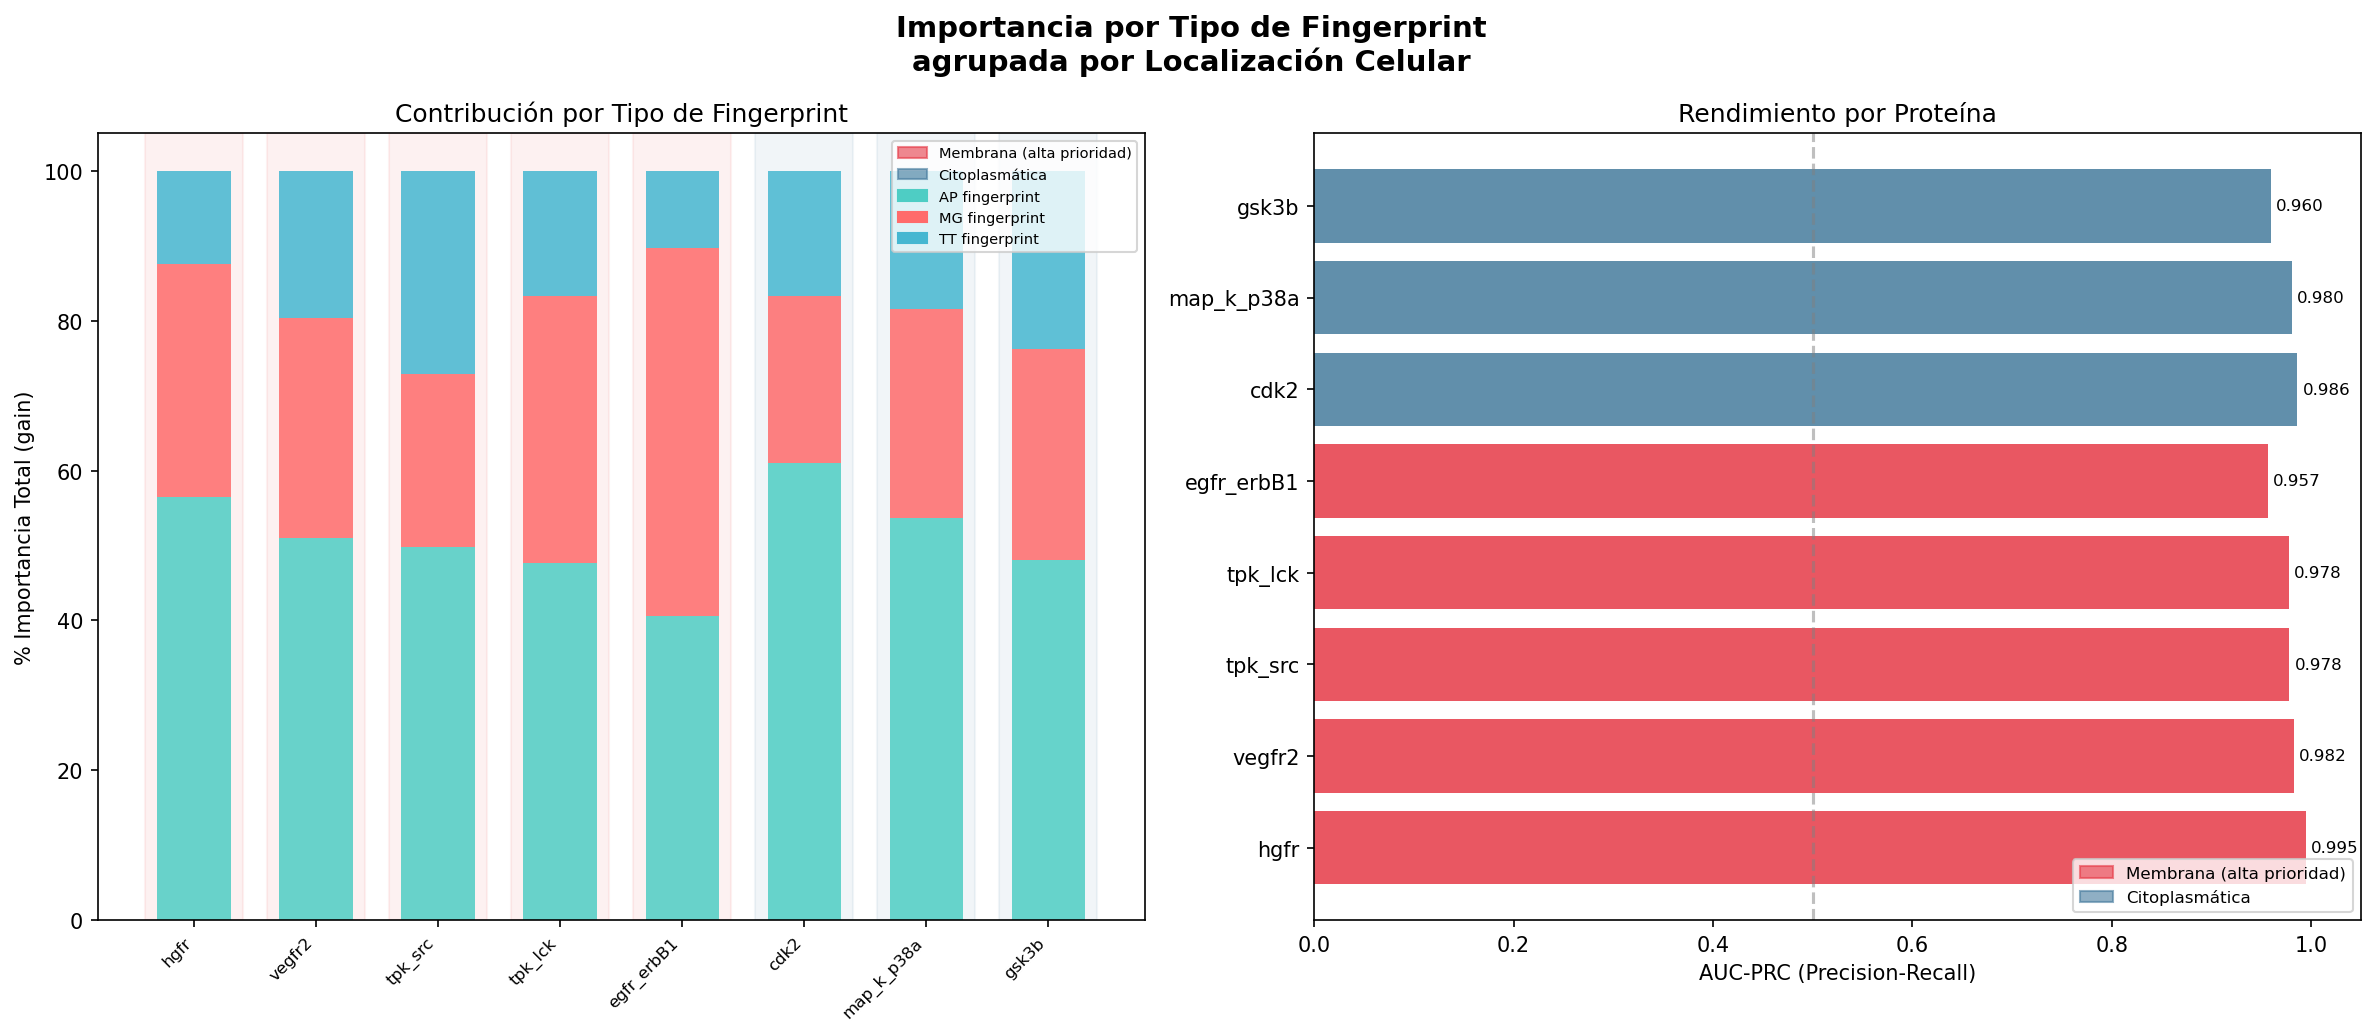

In [8]:
from IPython.display import Image, display
display(Image(interpretation.plot_fingerprint_importance(all_summaries, all_results)))


17:31:03 | INFO | Guardado: /Users/fabian/Downloads/CanInh-Model/results/plots/roc_prc_curves.png


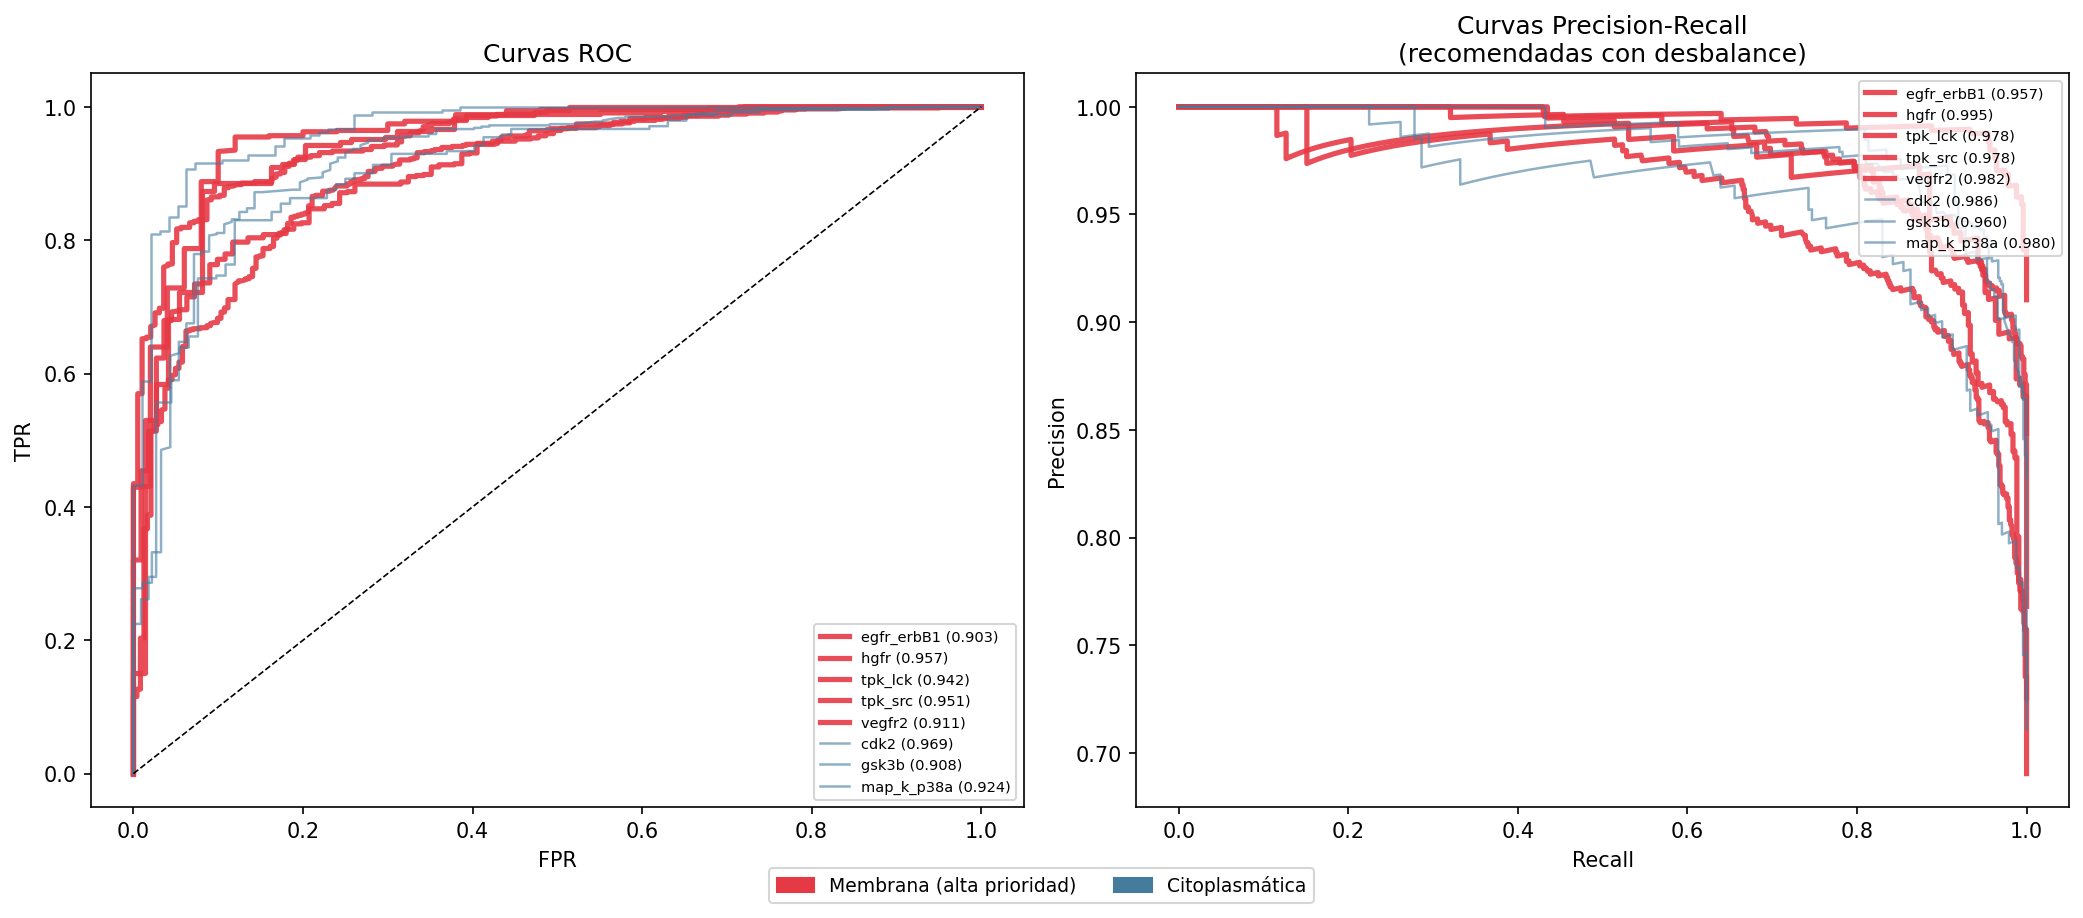

In [9]:
from IPython.display import Image, display
display(Image(interpretation.plot_roc_prc_curves(all_results)))


17:31:03 | INFO | Guardado: /Users/fabian/Downloads/CanInh-Model/results/plots/membrane_vs_interior_analysis.png
17:31:03 | INFO | 
 INTERPRETACIÓN BIOQUÍMICA:
17:31:03 | INFO |   AUC-PRC membrana=0.978  interior=0.975  diff=+0.003
17:31:03 | INFO |   MG% membrana=33.7  interior=26.1
17:31:03 | INFO |   → Proteínas de membrana más predecibles (sitio más accesible)
17:31:03 | INFO |   → Mayor importancia Morgan en membrana (entorno local más informativo)


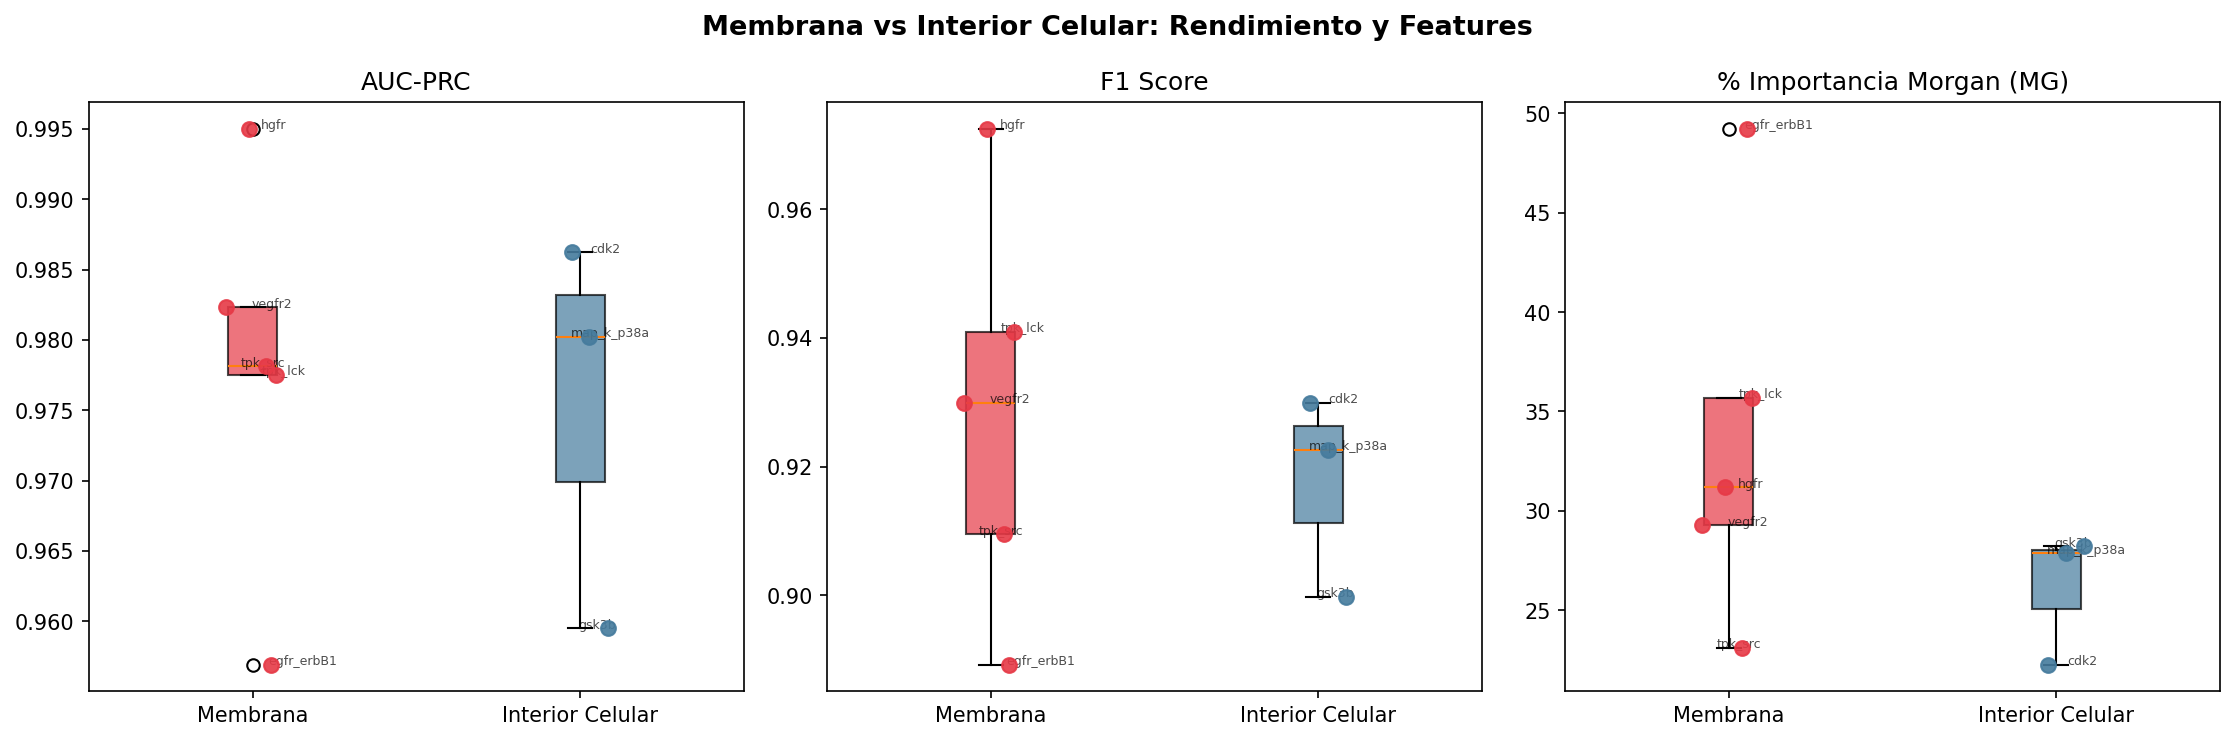

In [10]:
from IPython.display import Image, display
interpretation.analyze_membrane_vs_interior(all_results, all_summaries)
# plots_dir() es la función pública que resuelve la ruta en runtime
display(Image(str(interpretation.plots_dir() / 'membrane_vs_interior_analysis.png')))


## 4. Inspección por proteína

Cambia `TARGET`:
`cdk2` | `egfr_erbB1` | `gsk3b` | `hgfr` | `map_k_p38a` | `tpk_lck` | `tpk_src` | `vegfr2`

17:31:03 | INFO | Guardado: /Users/fabian/Downloads/CanInh-Model/results/plots/top_features_egfr_erbB1.png


Epidermal growth factor receptor (ErbB1/HER1)
Localización: membrane | Familia: RTK
Relevancia clínica: Oncogén en cáncer de pulmón/mama/colon. Diana de gefitinib, erlotinib.


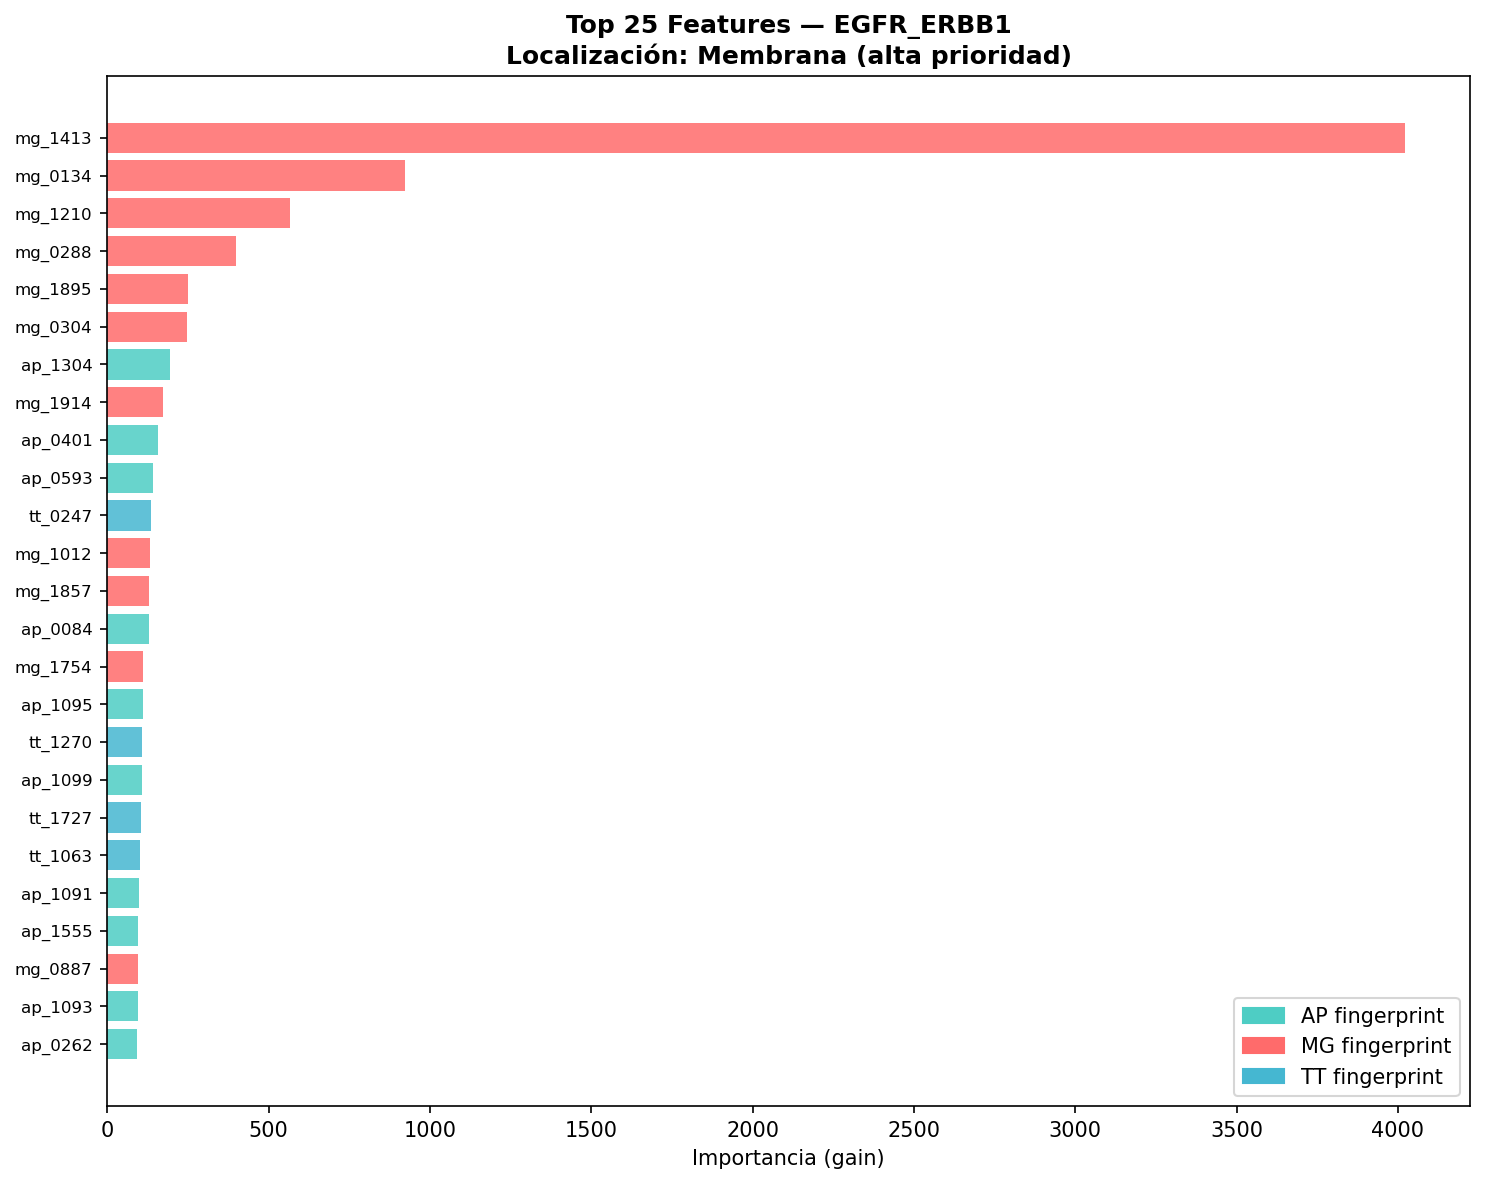

In [11]:
from IPython.display import Image, display

TARGET = 'egfr_erbB1'

if TARGET in boosters:
    meta = proteins[TARGET]['metadata']
    print(f'{meta["full_name"]}')
    print(f'Localización: {meta["location"]} | Familia: {meta["family"]}')
    print(f'Relevancia clínica: {meta.get("relevance","")}')
    display(Image(interpretation.plot_top_features(
        boosters[TARGET], TARGET, meta['location'], top_n=25)))
else:
    print(f'No encontrada. Disponibles: {list(boosters.keys())}')


## 5. Predicción sobre moléculas nuevas

In [13]:
import importlib
from src import virtual_screening
from src.config import OUTPUT_DIR
importlib.reload(virtual_screening)

print("Iniciando el Virtual Screening masivo sobre PubChem (70,249 moléculas)...")
df_hits = virtual_screening.run_virtual_screening(
    models_dir=OUTPUT_DIR / "models",
    output_dir=OUTPUT_DIR,
    top_n=20
)
if df_hits is not None:
    print("\n Top 10 Candidatos a Fármacos:")
    # Damos un poco de estilo a la tabla para que se vea profesional
    display(df_hits.head(10).style.background_gradient(subset=['Probabilidad_Inhibicion'], cmap='Blues'))

17:35:45 | INFO | Cargando librería de PubChem: pubchem_neg_sample.h5


Iniciando el Virtual Screening masivo sobre PubChem (70,249 moléculas)...


17:35:46 | INFO | Cargadas 75723 moléculas con 6117 features iniciales.
17:35:46 | INFO | Evaluando contra diana: TPK_LCK...
17:35:47 | INFO | Evaluando contra diana: TPK_SRC...
17:35:47 | INFO | Evaluando contra diana: HGFR...
17:35:47 | INFO | Evaluando contra diana: VEGFR2...
17:35:48 | INFO | Evaluando contra diana: EGFR_ERBB1...
17:35:48 | INFO | 
🎉 Virtual Screening Completado.
17:35:48 | INFO | Top candidatos guardados en: /Users/fabian/Downloads/CanInh-Model/results/pubchem_top_hits_screening.csv



 Top 10 Candidatos a Fármacos:


,Proteina_Diana,Rank,PubChem_CID,Probabilidad_Inhibicion
0,tpk_lck,1,68058875,0.999300
1,tpk_lck,2,67593796,0.998500
2,tpk_lck,3,68058868,0.997600
3,tpk_lck,4,58289963,0.996900
4,tpk_lck,5,11787144,0.996100
5,tpk_lck,6,20817357,0.995500
6,tpk_lck,7,21137598,0.995300
7,tpk_lck,8,66676710,0.994600
8,tpk_lck,9,77591037,0.993200
9,tpk_lck,10,69460341,0.993100


In [15]:
import pandas as pd
import plotly.express as px
from src.config import OUTPUT_DIR

# 1. Cargar los resultados del screening
df_hits = pd.read_csv(OUTPUT_DIR / "pubchem_top_hits_screening.csv")

# 2. Mapear la localización celular biológica
# (Ajusta los nombres exactos según como aparezcan en tu CSV)
loc_map = {
    "cdk2": "Citoplasmática", 
    "egfr_erbB1": "Membrana", 
    "gsk3b": "Citoplasmática",
    "hgfr": "Membrana", 
    "map_k_p38a": "Citoplasmática", 
    "tpk_lck": "Membrana",
    "tpk_src": "Membrana", 
    "vegfr2": "Membrana"
}

# Inyectamos la localización al DataFrame
df_hits['Localizacion'] = df_hits['Proteina_Diana'].str.lower().map(loc_map).fillna("Desconocida")

# 3. Crear el gráfico interactivo de dispersión (Dot Plot / Strip Plot)
fig = px.strip(
    df_hits,
    x="Proteina_Diana",
    y="Probabilidad_Inhibicion",
    color="Localizacion",
    hover_data=["PubChem_CID", "Rank"], # Esto aparecerá al pasar el mouse
    stripmode="overlay",
    title="Virtual Screening: Top Candidatos a Fármacos por Quinasa",
    labels={
        "Proteina_Diana": "Proteína Diana (Kinase)", 
        "Probabilidad_Inhibicion": "Probabilidad de Inhibición",
        "Localizacion": "Ubicación Celular"
    },
    color_discrete_map={"Membrana": "#E63946", "Citoplasmática": "#457B9D"}
)

# Añadir línea de corte de alta confianza
fig.add_hline(y=0.95, line_dash="dash", line_color="red", annotation_text=" Alta Confianza (>0.95)")

# Mejorar el diseño para presentación
fig.update_layout(
    template="plotly_white",
    hovermode="closest",
    height=600
)

fig.show()